# Chapter 4 NumPy机器学习编程

## 4.1数组的归一化标准化算法

### 4.1.2 z-score normalization （标准化）

In [1]:
import numpy as np

In [2]:
def zscore(x, axis = None):
    xmean = x.mean(axis=axis, keepdims=True)
    xstd = np.std(x, axis=axis, keepdims=True)
    zscore = (x-xmean)/xstd
    return zscore

In [3]:
a = np.random.randint(10, size=(2, 5))

In [4]:
a # 生成10个随机数

array([[6, 4, 2, 0, 8],
       [9, 8, 0, 5, 8]])

In [5]:
zscore(a)

array([[ 0.31008684, -0.31008684, -0.93026051, -1.55043418,  0.93026051],
       [ 1.24034735,  0.93026051, -1.55043418,  0.        ,  0.93026051]])

In [6]:
zscore(a, axis=1)

array([[ 0.70710678,  0.        , -0.70710678, -1.41421356,  1.41421356],
       [ 0.91287093,  0.60858062, -1.82574186, -0.30429031,  0.60858062]])

In [7]:
b = zscore(a, axis=1)

In [8]:
b

array([[ 0.70710678,  0.        , -0.70710678, -1.41421356,  1.41421356],
       [ 0.91287093,  0.60858062, -1.82574186, -0.30429031,  0.60858062]])

In [9]:
b.sum(axis=1)

array([0.00000000e+00, 1.11022302e-16])

In [10]:
b.std(axis=1)

array([1., 1.])

### 4.1.3 min-max normalization

In [11]:
import numpy as np

In [12]:
def min_max(x, axis=None):
    min = x.min(axis=axis, keepdims=True)
    max = x.max(axis=axis, keepdims=True)
    result = (x-min)/(max-min)
    return result

In [13]:
b = np.random.randint(10, size=(2, 5))

In [14]:
b

array([[4, 6, 3, 6, 2],
       [8, 6, 6, 3, 3]])

In [15]:
c = min_max(b)

In [16]:
c

array([[0.33333333, 0.66666667, 0.16666667, 0.66666667, 0.        ],
       [1.        , 0.66666667, 0.66666667, 0.16666667, 0.16666667]])

In [17]:
d = min_max(b, axis=1)

In [18]:
d

array([[0.5 , 1.  , 0.25, 1.  , 0.  ],
       [1.  , 0.6 , 0.6 , 0.  , 0.  ]])

### 4.1.4 　向量的归一化

In [19]:
import numpy as np

In [20]:
def normalize(v, axis=-1, order=2):
    l2 = np.linalg.norm(v, ord=order, axis=axis, keepdims=True)
    l2[l2==0] = 1
    return v/l2

In [21]:
a = np.array([1, 2, 3, 2, 1])

In [22]:
b = normalize(a)

In [23]:
b

array([0.22941573, 0.45883147, 0.6882472 , 0.45883147, 0.22941573])

In [24]:
(b*b).sum()

0.9999999999999997

In [25]:
c = np.random.randint(10, size=(3,4))

In [26]:
c

array([[2, 8, 7, 8],
       [4, 6, 8, 8],
       [8, 1, 1, 2]])

In [27]:
d = normalize(c, axis=None) #对所有的元素进行归一化处理

In [28]:
d

array([[0.10315166, 0.41260662, 0.36103079, 0.41260662],
       [0.20630331, 0.30945497, 0.41260662, 0.41260662],
       [0.41260662, 0.05157583, 0.05157583, 0.10315166]])

In [29]:
(d*d).sum()

1.1464884423149386

In [30]:
e = normalize(c, axis=1)

In [31]:
e

array([[0.14865883, 0.59463532, 0.5203059 , 0.59463532],
       [0.2981424 , 0.4472136 , 0.59628479, 0.59628479],
       [0.95618289, 0.11952286, 0.11952286, 0.23904572]])

In [32]:
f = np.random.randint(10, size=(2, 3, 4))

In [33]:
normalize(f, axis=(1, 2))

array([[[0.46061057, 0.05757632, 0.11515264, 0.17272896],
        [0.51818689, 0.        , 0.2878816 , 0.17272896],
        [0.51818689, 0.2878816 , 0.23030528, 0.11515264]],

       [[0.12708739, 0.57189327, 0.        , 0.31771848],
        [0.44480587, 0.19063109, 0.31771848, 0.12708739],
        [0.12708739, 0.44480587, 0.12708739, 0.44480587]]])

## 4.2 线性回归的NumPy编程

### 4.2.4 NumPy代码的编写

In [34]:
import numpy as np

In [35]:
X = np.random.rand(20)*8-4 #  –4～4内均匀分布的随机数

In [36]:
X

array([ 0.08895529, -1.1207198 ,  2.40321622,  2.19129211,  2.50209589,
       -3.67664423, -2.14535824,  2.35822925, -1.82378954, -0.70907684,
       -1.48429851, -1.24124041, -0.53195024, -0.80828069,  3.64591567,
       -3.50568339, -3.54664013,  0.87743059, -3.69190135, -2.29274601])

In [37]:
y = np.sin(X) + np.random.randn(20)*0.2 # 在正弦曲线的值中加入噪声

In [38]:
y

array([ 0.01000885, -1.33530922,  0.80273092,  0.69717847,  0.6490312 ,
        0.43127809, -1.07224767,  0.87138599, -1.22370151, -0.54879218,
       -1.0973055 , -1.05910811, -0.34560763, -0.59333123, -0.67095942,
        0.49860156,  0.56399234,  0.80717785,  0.73944243, -0.68887988])

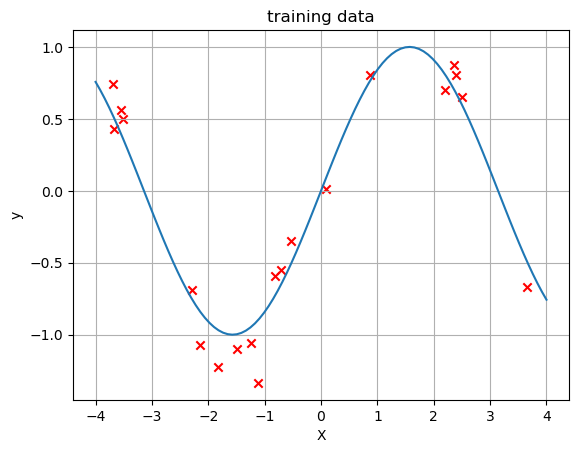

In [39]:
import matplotlib.pyplot as plt

XX = np.linspace(-4, 4, 100) #生成将–4～4内的空间均分为100等分的数列
plt.xlabel('X')
plt.ylabel('y')

plt.title('training data')

plt.grid()

plt.scatter(X, y, marker='x', c='red') # 用marker设置点的形状，c设置颜色，并生成散点图

plt.plot(XX, np.sin(XX)) #  绘制正弦曲线

plt.show()

In [40]:
A = np.empty((6,6)) # 创建保存矩阵A的容器

In [41]:
for i in range(6):
    for j in range(6):
        A[i][j] = np.sum(X**(i+j))

In [42]:
A

array([[ 2.00000000e+01, -1.25111944e+01,  1.08110123e+02,
        -1.21013990e+02,  1.05103858e+03, -1.64340739e+03],
       [-1.25111944e+01,  1.08110123e+02, -1.21013990e+02,
         1.05103858e+03, -1.64340739e+03,  1.22150263e+04],
       [ 1.08110123e+02, -1.21013990e+02,  1.05103858e+03,
        -1.64340739e+03,  1.22150263e+04, -2.23396643e+04],
       [-1.21013990e+02,  1.05103858e+03, -1.64340739e+03,
         1.22150263e+04, -2.23396643e+04,  1.52476824e+05],
       [ 1.05103858e+03, -1.64340739e+03,  1.22150263e+04,
        -2.23396643e+04,  1.52476824e+05, -2.98161478e+05],
       [-1.64340739e+03,  1.22150263e+04, -2.23396643e+04,
         1.52476824e+05, -2.98161478e+05,  1.96253775e+06]])

In [43]:
b = np.empty(6)

In [44]:
for i in range(6):
    b[i] = np.sum(X**i*y)

In [45]:
b

array([   -2.56441467,     8.93873386,    18.61190236,   -62.81908916,
         292.23197503, -1451.69376752])

In [46]:
omega = np.dot(np.linalg.inv(A), b.reshape(-1, 1)) # 使用np.linalg.inv()得到逆矩阵，使用np.dot计算内积

In [47]:
omega

array([[ 1.80976201e-02],
       [ 1.07354093e+00],
       [-1.32287350e-02],
       [-1.60210988e-01],
       [ 7.29098087e-04],
       [ 5.00119983e-03]])

In [48]:
omega.shape

(6, 1)

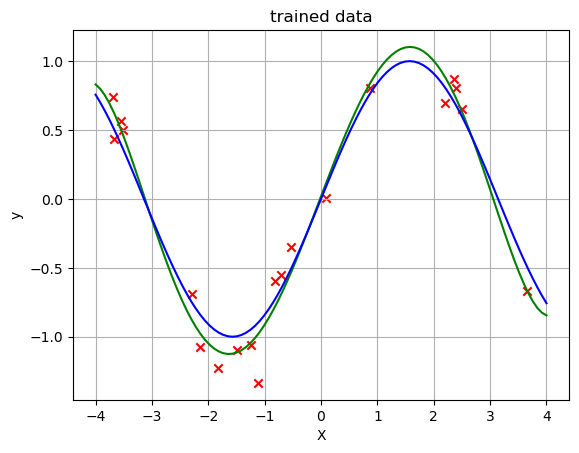

In [49]:
f = np.poly1d(omega.flatten()[::-1]) # 生成将 ω 作为系数的多项式

XX = np.linspace(-4, 4, 100)

plt.xlabel('X')

plt.ylabel('y')

plt.title('trained data')

plt.grid()

plt.scatter(X, y, marker='x', c='red')

plt.plot(XX, f(XX), color='green')

plt.plot(XX, np.sin(XX), color='blue')

plt.show()


### 4.2.5 函数的多项式拟合

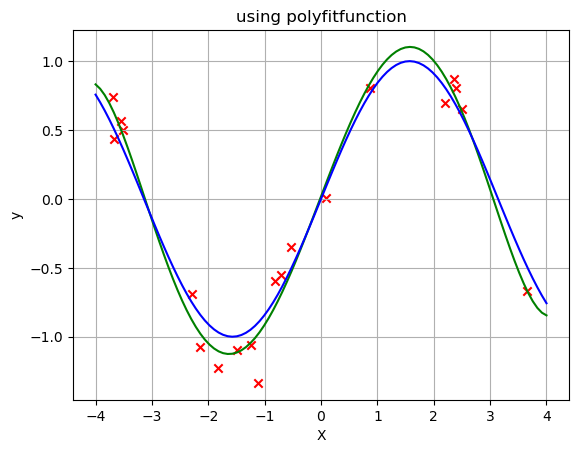

In [50]:
omega_2 = np.polyfit(X, y, 5)

omega_2

f_2 = np.poly1d(omega_2)

f = np.poly1d(omega.flatten()[::-1])

XX = np.linspace(-4, 4, 100) 

plt.xlabel('X')

plt.ylabel('y')

plt.title('using polyfitfunction')

plt.grid()

plt.scatter(X, y, marker='x', c='red')

plt.plot(XX, f(XX), color='green')

plt.plot(XX, np.sin(XX), color='blue')

plt.show()


## 4.5 NumPy 神经网络编程（实践篇）

### 4.5.2 数据集的准备

```bash
［终端窗口］
$ wget https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

［终端窗口］
$ pip install pandas
```

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
df = pd.read_csv('iris.data', header=None) #读入之前下载的iris.data文件
print(df) #显示文件的内容
y = df.iloc[0:100,4].values #从数据的内容可以看出，开头的100组数据是Iris setona和Iris virginica的部分，将其中的标签数据单独提取出来
y = np.where(y=='Iris-setona', -1, 1) ##从数据的内容可以看出，开头的100组数据是Iris setona和Iris virginica的部分，将其中的标签数据单独提取出来
X = df.iloc[0:100,[0, 1, 2, 3]].values #  1~4号数据是在学习中需要使用的，因此将其提取出来

       0    1    2    3               4
0    5.1  3.5  1.4  0.2     Iris-setosa
1    4.9  3.0  1.4  0.2     Iris-setosa
2    4.7  3.2  1.3  0.2     Iris-setosa
3    4.6  3.1  1.5  0.2     Iris-setosa
4    5.0  3.6  1.4  0.2     Iris-setosa
..   ...  ...  ...  ...             ...
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica

[150 rows x 5 columns]


### 4.5.3　训练数据和测试数据的划分

In [52]:
X_train = np.empty((80, 4)) # 创建用于存放数据的空数组
X_test = np.empty((20, 4))
y_train = np.empty(80)
y_test = np.empty(20)
X_train[:40],X_train[40:] = X[:40],X[50:90]
X_test[:10],X_test[10:] = X[40:50],X[90:100]
y_train[:40],y_train[40:] = y[:40],y[50:90]
y_test[:10],y_test[10:] = y[40:50],y[90:100]

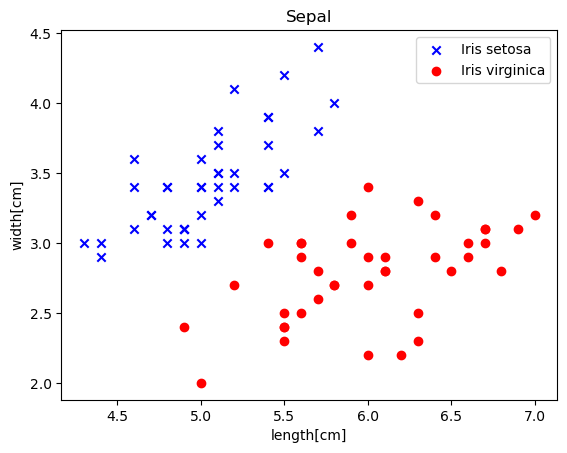

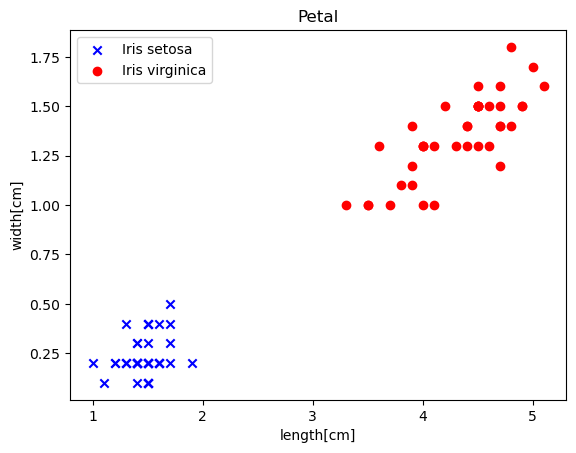

In [53]:
plt.title('Sepal') # 萼片
plt.xlabel('length[cm]')
plt.ylabel('width[cm]')
plt.scatter(X_train[:40, 0], X_train[:40, 1],marker='x', color='blue', label='Iris setosa')
plt.scatter(X_train[40:, 0], X_train[40:, 1],marker='o', color='red', label='Iris virginica')
plt.legend()
plt.show()

# 接下来是花瓣
plt.title('Petal') #花瓣
plt.xlabel('length[cm]')
plt.ylabel('width[cm]')
plt.scatter(X_train[:40,2], X_train[:40, 3],marker='x', color='blue', label='Iris setosa')
plt.scatter(X_train[40:, 2], X_train[40:, 3],marker='o', color='red', label='Iris virginica')
plt.legend()
plt.show()

### 4.5.4　神经网络的构建

In [54]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def activation(X, w, b):
    return sigmoid(np.dot(X, w)+b)

def loss(X, y, w, b):
    dif = y - activation(X, w, b)
    return np.sum(dif**2/(2*len(y)),keepdims=True)

def accuracy(X, y, w, b):
    pre = predict(X, w, b)
    return np.sum(np.where(pre==y, 1, 0))/len(y)

def predict(X, w, b):
    result = np.where(activation(X, w, b)<0.5, -1.0, 1.0)
    return result

def update(X, y, w, b, eta): # 对权重进行更新，其中eta为学习率
    a = (activation(X, w, b)-y)*activation(X, w, b)*(1-activation(X, w, b))
    a = a.reshape(-1, 1)
    w -= eta * 1/float(len(y))*np.sum(a*X, axis=0)
    b -= eta * 1/float(len(y))*np.sum(a)
    return w, b

def update_2(X, y, w, b, eta): # 将w和b的值分别稍微调大时，用偏微分计算输出值的变化情况
    h = 1e-4
    loss_origin = loss(X, y, w, b)
    delta_w = np.zeros_like(w)
    delta_b = np.zeros_like(b)
    for i in range(4):
        tmp = w[i]
        w[i] += h # 将参数中的一个值稍微调大一点
        loss_after = loss(X, y, w, b)
        delta_w[i] = eta*(loss_after - loss_origin)/h
        w[i] = tmp
    tmp = b
    b += h
    loss_after = loss(X, y, w, b)
    delta_b = eta*(loss_after - loss_origin)/h
    w -= delta_w #  更新参数值
    b = tmp - delta_b
    return w, b

In [55]:
weights_1 = np.ones(4)/10 # w的初始值全部设为0.1
bias_1 = np.ones(1)/10 #b的初始值也设为0.1
weights_2 = np.ones(4)/10
bias_2 = np.ones(1)/10
for _ in range(15): # 先让模型进行15次学习
    weights_1, bias_1 = update(X_train, y_train, weights_1, bias_1, eta=0.1)
    weights_2, bias_2 = update(X_train , y_train, weights_2, bias_2, eta=0.1)
    print('acc_1 %f, loss_1 %f, acc_2 %f, loss_2 %f' % ( accuracy(X_test, y_test, weights_1, bias_1), \
    loss(X_test, y_test, weights_1, bias_1)\
    ,accuracy(X_test, y_test, weights_2, bias_2), loss(X_test, y_test, weights_2, bias_2)))
print('weights_1 = ', weights_1, 'bias_1 = ', bias_1)
print('weights_2 = ', weights_2, 'bias_2 = ', bias_2)

acc_1 1.000000, loss_1 0.019286, acc_2 1.000000, loss_2 0.019286
acc_1 1.000000, loss_1 0.015770, acc_2 1.000000, loss_2 0.015770
acc_1 1.000000, loss_1 0.013320, acc_2 1.000000, loss_2 0.013320
acc_1 1.000000, loss_1 0.011520, acc_2 1.000000, loss_2 0.011520
acc_1 1.000000, loss_1 0.010142, acc_2 1.000000, loss_2 0.010142
acc_1 1.000000, loss_1 0.009056, acc_2 1.000000, loss_2 0.009056
acc_1 1.000000, loss_1 0.008177, acc_2 1.000000, loss_2 0.008177
acc_1 1.000000, loss_1 0.007452, acc_2 1.000000, loss_2 0.007452
acc_1 1.000000, loss_1 0.006844, acc_2 1.000000, loss_2 0.006844
acc_1 1.000000, loss_1 0.006327, acc_2 1.000000, loss_2 0.006327
acc_1 1.000000, loss_1 0.005883, acc_2 1.000000, loss_2 0.005883
acc_1 1.000000, loss_1 0.005496, acc_2 1.000000, loss_2 0.005496
acc_1 1.000000, loss_1 0.005156, acc_2 1.000000, loss_2 0.005156
acc_1 1.000000, loss_1 0.004856, acc_2 1.000000, loss_2 0.004856
acc_1 1.000000, loss_1 0.004589, acc_2 1.000000, loss_2 0.004589
weights_1 =  [0.22314177 

/tmp/ipykernel_205876/102798932.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('acc_1 %f, loss_1 %f, acc_2 %f, loss_2 %f' % ( accuracy(X_test, y_test, weights_1, bias_1), \


## 4.7 NumPy神经网络编程（文字识别篇）

### 4.7.1　基于NumPy的实现 （MNIST）

```bash
［终端窗口］
$ wget http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz
$ wget http://yann.lecun.com/exdb/mnist/train-labels-idx1-ubyte.gz
$ wget http://yann.lecun.com/exdb/mnist/t10k-images-idx3-ubyte.gz
$ wget http://yann.lecun.com/exdb/mnist/t10k-labels-idx1-ubyte.gz
```

In [57]:
import load_mnist as lm
dataset = lm.load_mnist()

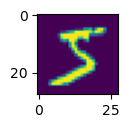

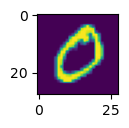

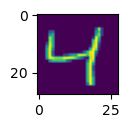

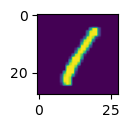

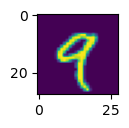

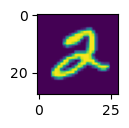

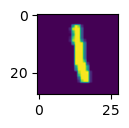

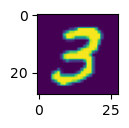

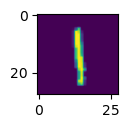

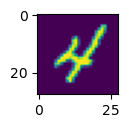

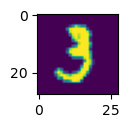

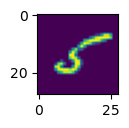

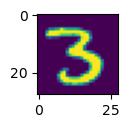

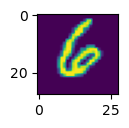

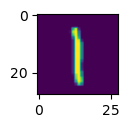

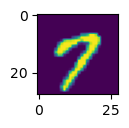

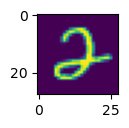

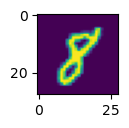

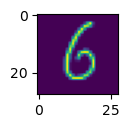

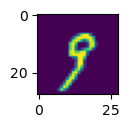

In [58]:
import matplotlib.pyplot as plt

for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(dataset['x_train'][i,:].reshape(28, 28))

    plt.show()

### 4.7.3　网络的训练

In [72]:
import importlib
import neuralnet
importlib.reload(neuralnet)

<module 'neuralnet' from '/home/hexu/git/python-data-science-examples/Numpy.Data.Processing.Detailed.Explanation/Chapter4/neuralnet.py'>

In [73]:
import numpy as np
import neuralnet as nl
import load_mnist

dataset = load_mnist.load_mnist()
X_train = dataset['x_train']
t_train = dataset['t_train']
X_test = dataset['x_test']
t_test = dataset['t_test']

weight_list, bias_list = nl.make_params([784, 100, 10])
# 指定进行多少次学习
train_time = 10000
# 指定每次学习使用多少个样本数据
batch_size = 1000
#创建用于记录精度和损失的变化情况的数组
total_acc_list = []
total_loss_list = []
for i in range(train_time):

    #  生成batch_size个0～59999内的随机整数
    ra = np.random.randint(60000, size=batch_size)
    # 在这里进行参数的更新操作。eta为学习率，用于决定参数按照多大比例进行更新
    # 将学习率设置为2.0
    # 在实际中往往需要反复尝试才能确定学习率
    x_batch, t_batch = X_train[ra,:], t_train[ra,:]
    weight_list, bias_list = nl.update(x_batch, weight_list, bias_list, t_batch, eta=2.0)
    # 每学习5次对学习进度进行确认
    if (i+1)%100 == 0:
        acc_list = []
        loss_list = []
        for k in range(10000//batch_size):
            x_batch, t_batch = X_test[k*batch_size:(k+1)*batch_size, :], t_test[k*batch_size:(k+1)*batch_size, :]
            acc_val = nl.accuracy(x_batch, weight_list, bias_list, t_batch)
            loss_val = nl.loss(x_batch, weight_list, bias_list, t_batch)
            acc_list.append(acc_val)
            loss_list.append(loss_val)
        # 计算精度的平均值
        acc = np.mean(acc_list)
        # 计算损失总和
        loss = np.mean(loss_list)
        total_acc_list.append(acc)
        total_loss_list.append(loss)
        print("Time: %d, Accuracy: %f, Loss: %f"%(i+1, acc, loss))

Time: 100, Accuracy: 0.395900, Loss: 0.398169
Time: 200, Accuracy: 0.611100, Loss: 0.263681
Time: 300, Accuracy: 0.703900, Loss: 0.206580
Time: 400, Accuracy: 0.755300, Loss: 0.176180
Time: 500, Accuracy: 0.779000, Loss: 0.158628
Time: 600, Accuracy: 0.796500, Loss: 0.145836
Time: 700, Accuracy: 0.810400, Loss: 0.136615
Time: 800, Accuracy: 0.821400, Loss: 0.129481
Time: 900, Accuracy: 0.831200, Loss: 0.124006
Time: 1000, Accuracy: 0.837600, Loss: 0.119892
Time: 1100, Accuracy: 0.844500, Loss: 0.114996
Time: 1200, Accuracy: 0.846800, Loss: 0.112533
Time: 1300, Accuracy: 0.853100, Loss: 0.108486
Time: 1400, Accuracy: 0.856700, Loss: 0.106011
Time: 1500, Accuracy: 0.859200, Loss: 0.103257
Time: 1600, Accuracy: 0.862400, Loss: 0.101582
Time: 1700, Accuracy: 0.866300, Loss: 0.099249
Time: 1800, Accuracy: 0.868500, Loss: 0.097745
Time: 1900, Accuracy: 0.871600, Loss: 0.096132
Time: 2000, Accuracy: 0.873600, Loss: 0.094646
Time: 2100, Accuracy: 0.874500, Loss: 0.092863
Time: 2200, Accuracy: 

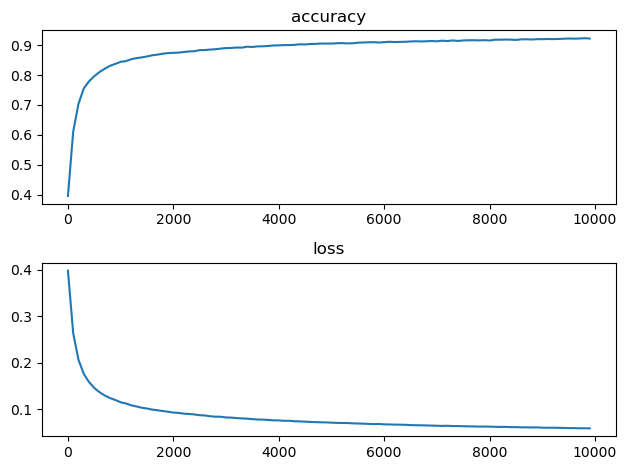

In [74]:
import matplotlib.pyplot as plt
plt.subplot(211)
plt.plot(np.arange(0, train_time, 100),total_acc_list)
plt.title('accuracy')
plt.subplot(212)
plt.plot(np.arange(0, train_time, 100), total_loss_list)
plt.title('loss')
plt.tight_layout()
plt.show()

## 4.8 NumPy神经网络编程（强化学习篇）

### 4.8.2　　游戏的安装与执行

```bash
［终端窗口］
$ pip install gym
```

In [77]:
import gym
env = gym.make("CartPole-v0")

/home/hexu/anaconda3/lib/python3.12/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


In [78]:
observation = env.reset()

In [81]:
action = 1 #先尝试往右推底座
observation, reward, done, _, info = env.step(action) #  执行step函数就会返回采取行动后的状态、报酬、游戏是否已经结束、信息4个变量

In [83]:
import numpy as np
observation = env.reset()

for k in range(100):
    env.render()
    #  用0或1随机执行
    observation, reward, done, _, info=env.step(np.random.randint(1))
# 游戏结束时需要调用env.close方法
env.close()

/home/hexu/anaconda3/lib/python3.12/site-packages/gym/envs/classic_control/cartpole.py:177: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(
